In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
paths = [
    '../training/runs/sigma4/sigma4_size17_seed0',
    '../training/runs/sigma4/sigma4_size17_seed42',
    '../training/runs/sigma4/sigma4_size17_seed123',
]

models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [ ]:
model = models[0]

features = []
for key in data_keys:
    batch_features = []
    for batch in dataloaders['validation'][key]:
        img, target, behav = batch[:3]
        img = img.to(device)
        
        if len(batch) == 4:
            pupil = batch[3]
            pupil = pupil.to(device)
        elif len(batch) == 3:
            pupil = None

        pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
        feature = feature.detach().cpu()
        batch_features.append(feature)
    features.append(torch.cat(batch_features))

flattened = torch.cat([f.flatten(0, 1) for f in features])

# before whitening

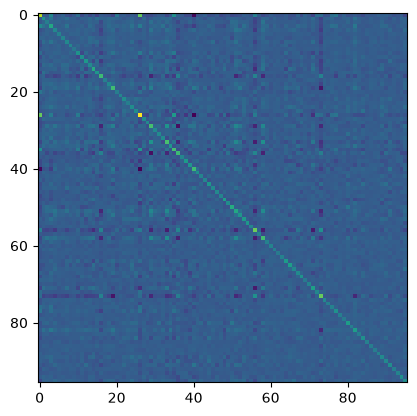

In [ ]:
X = flattened
Xc = X - X.mean(0)
cov = Xc.T @ Xc / (X.shape[0] - 1)
plt.imshow(cov, colorbar)

# after whitening

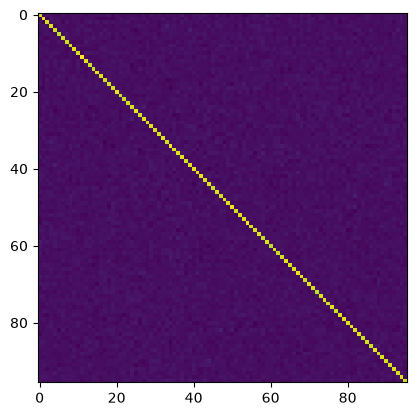

In [47]:
w_mu = model.whitener.mu_ema.cpu()
w_cov = model.whitener.cov_ema.cpu()

eye = torch.eye(w_cov.shape[0], dtype=w_cov.dtype, device=w_cov.device)
L = torch.linalg.cholesky(w_cov + 1e-5 * eye)
W = torch.linalg.inv(L).T

centered = flattened - w_mu
whitened = centered @ W

after_cov = whitened.T @ whitened / (whitened.shape[0] - 1)
plt.imshow(after_cov)